# 04. Visualizations: Comfort Picks vs. Assigned Picks

This notebook is **visualization-only** — it does no new statistical computation. Everything it plots comes from CSVs exported by `03_stats_analysis.ipynb`. If any of those files are missing, run `03` top to bottom first (as of the current version, it exports each CSV right after computing it, so a partial run still leaves behind whatever it reached).

| Input CSV | Figure |
|---|---|
| `lmm_summary.csv` | Fig. 1 — forest plot of the LMM comfort effect |
| `paired_test_results.csv` + `player_comfort_means_wide.csv` | Fig. 2 — per-player paired comparison |
| `comfort_effect_by_player.csv` | Fig. 3 — effect heterogeneity by role, Fig. 4 — top/bottom players |
| `model_df_with_elo.csv` | Fig. 5 — selection bias by opponent-strength quintile |

**What changed vs. an earlier version:** Figure 1 previously plotted the LMM's `is_comfort` coefficients in each metric's *raw* units on a single shared axis — but GD@15 (tens/hundreds of gold), DPM (tens), and DMG% or KDA (fractions of a point) live on wildly different scales, so GD@15/XPD@15 visually dominated the chart just because their numbers happen to be bigger, not because the effect was actually stronger. Figure 1 now plots **standardized coefficients** (in standard deviations of each metric) so effects are genuinely comparable across metrics, with the raw values annotated next to each point for interpretability.

In [1]:
import os

DATA_DIR = "data/processed"

print(f"1. Does '{DATA_DIR}' exist? {os.path.isdir(DATA_DIR)}")
if os.path.isdir(DATA_DIR):
    print(f"2. Contents of '{DATA_DIR}':")
    for f in sorted(os.listdir(DATA_DIR)):
        print(f"   - {f}")
    print(f"3. Files found: {sorted(os.listdir(DATA_DIR))}")

1. Does 'data/processed' exist? True
2. Contents of 'data/processed':
   - comfort_effect_by_player.csv
   - lmm_summary.csv
   - model_df_with_elo.csv
   - ols_robustness_check.csv
   - paired_test_results.csv
   - player_comfort_means_wide.csv
   - player_games_classified.csv
   - player_games_clean.csv
   - selection_bias_logit_summary.csv
3. Files found: ['comfort_effect_by_player.csv', 'lmm_summary.csv', 'model_df_with_elo.csv', 'ols_robustness_check.csv', 'paired_test_results.csv', 'player_comfort_means_wide.csv', 'player_games_classified.csv', 'player_games_clean.csv', 'selection_bias_logit_summary.csv']


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300

# --- Brand palette, shared with the QA plot in 03_stats_analysis.ipynb ---
COLOR_COMFORT = "#1B998B"          # teal — comfort picks
COLOR_NOCOMFORT = "#E9724C"        # burnt orange — no-comfort / assigned picks
COLOR_NEUTRAL = "#9AA5AB"          # neutral grey — reference lines, boxplots
COLOR_SIGNIFICANT = "#1B998B"
COLOR_NOT_SIGNIFICANT = "#C6CCD1"

ALL_METRICS = {
    "golddiffat15": "GD@15",
    "csdiffat15": "CSD@15",
    "xpdiffat15": "XPD@15",
    "dpm": "DPM",
    "damageshare": "DMG%",
    "kda": "KDA",
}

FIG_DIR = "assets/figures"
os.makedirs(FIG_DIR, exist_ok=True)


def save_fig(fig, name: str):
    png_path = f"{FIG_DIR}/{name}.png"
    svg_path = f"{FIG_DIR}/{name}.svg"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")

## Part 0 — Load the outputs from 03_stats_analysis.ipynb

In [3]:
required_files = [
    "paired_test_results.csv",
    "player_comfort_means_wide.csv",
    "lmm_summary.csv",
    "comfort_effect_by_player.csv",
    "model_df_with_elo.csv",
]
missing_files = [f for f in required_files if not os.path.exists(f"{DATA_DIR}/{f}")]
if missing_files:
    raise FileNotFoundError(
        f"Missing input file(s): {missing_files}. "
        "Run 03_stats_analysis.ipynb top to bottom first -- as of the current "
        "version it exports each CSV right after computing it, so even a "
        "partial run leaves behind whichever files it already reached."
    )

paired_results = pd.read_csv(f"{DATA_DIR}/paired_test_results.csv")
wide = pd.read_csv(f"{DATA_DIR}/player_comfort_means_wide.csv")
lmm_summary = pd.read_csv(f"{DATA_DIR}/lmm_summary.csv")
comfort_effect = pd.read_csv(f"{DATA_DIR}/comfort_effect_by_player.csv")
model_df = pd.read_csv(f"{DATA_DIR}/model_df_with_elo.csv")

print(f"paired_results:    {paired_results.shape}")
print(f"wide:              {wide.shape}")
print(f"lmm_summary:       {lmm_summary.shape}")
print(f"comfort_effect:    {comfort_effect.shape} (metric: {comfort_effect['metric'].iloc[0]})")
print(f"model_df_with_elo: {model_df.shape}")

lmm_summary.round(3)

paired_results:    (6, 13)
wide:              (413, 15)
lmm_summary:       (6, 15)
comfort_effect:    (600, 7) (metric: GD@15)
model_df_with_elo: (21373, 37)


,metric,coef_is_comfort,se,p_value,ci_low,ci_high,coef_is_comfort_std,ci_low_std,ci_high_std,icc_player,n_obs,n_players,converged,p_fdr,significant_fdr
0,GD@15,67.475,12.169,0.000,43.624,91.327,0.078,0.050,0.105,0.055,21373,600,True,0.000,True
1,CSD@15,1.088,0.258,0.000,0.582,1.593,0.059,0.032,0.087,0.085,21373,600,True,0.000,True
2,XPD@15,59.965,10.963,0.000,38.478,81.452,0.077,0.049,0.104,0.054,21373,600,True,0.000,True
3,DPM,11.143,2.971,0.000,5.320,16.966,0.039,0.019,0.059,0.072,21373,600,True,0.000,True
4,DMG%,-0.054,0.082,0.511,-0.214,0.106,-0.006,-0.023,0.012,0.071,21373,600,True,0.511,False
5,KDA,0.898,0.071,0.000,0.758,1.037,0.172,0.145,0.199,0.028,21373,600,True,0.000,True


## Figure 1 — Adjusted comfort-pick effect per metric (LMM forest plot)

Each point is the `is_comfort` coefficient from the corresponding linear mixed model in `03_stats_analysis.ipynb` (Part 2), controlling for role, side and relative opponent strength, with the 95% confidence interval as a horizontal line. Color marks whether the effect survives Benjamini-Hochberg FDR correction. The x-axis is in **standard deviations of each metric**, so effects across very different scales (gold, CS, percentage points) can be read on equal footing — the raw (unstandardized) coefficient is printed next to each point.

Saved: assets/figures/fig1_forest_lmm_comfort_effect.png
Saved: assets/figures/fig1_forest_lmm_comfort_effect.svg


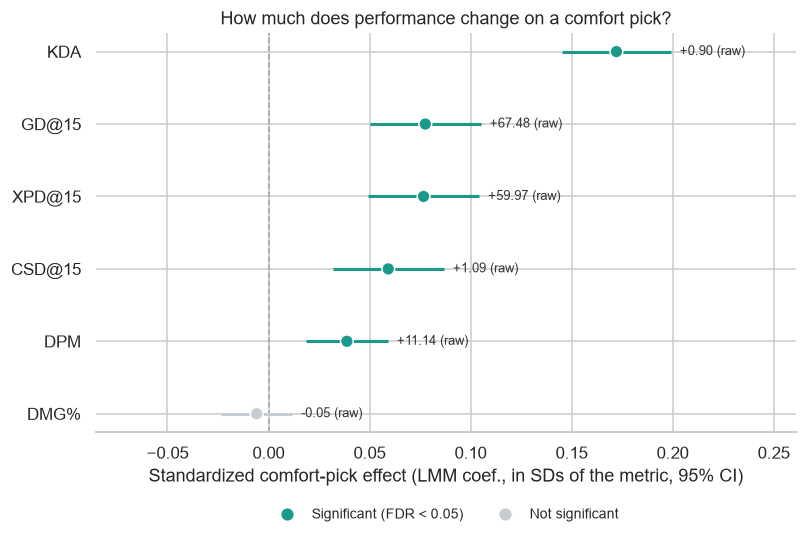

In [4]:
def plot_forest_lmm(lmm_df: pd.DataFrame, save_name: str = "fig1_forest_lmm_comfort_effect"):
    """
    Forest plot of the LMM's `is_comfort` coefficient per metric.

    Uses standardized coefficients (in SDs of each metric) so GD@15
    (measured in gold, typically hundreds) and KDA or DMG% (small numbers /
    percentage points) can be compared on the same axis without one metric
    visually dominating just because its raw units are bigger. Falls back
    to raw coefficients if the standardized columns aren't present (e.g.
    an older lmm_summary.csv), so this function still works either way.
    """
    use_std = {"coef_is_comfort_std", "ci_low_std", "ci_high_std"}.issubset(lmm_df.columns)
    coef_col = "coef_is_comfort_std" if use_std else "coef_is_comfort"
    lo_col = "ci_low_std" if use_std else "ci_low"
    hi_col = "ci_high_std" if use_std else "ci_high"

    d = lmm_df.sort_values(coef_col).reset_index(drop=True)
    y = np.arange(len(d))
    colors = np.where(d["significant_fdr"], COLOR_SIGNIFICANT, COLOR_NOT_SIGNIFICANT)

    fig, ax = plt.subplots(figsize=(7.5, 0.6 * len(d) + 1.5))
    ax.hlines(y, d[lo_col], d[hi_col], color=colors, linewidth=2, zorder=2)
    ax.scatter(d[coef_col], y, color=colors, s=70, zorder=3, edgecolor="white", linewidth=1)
    ax.axvline(0, color=COLOR_NEUTRAL, linestyle="--", linewidth=1, zorder=1)

    ax.set_yticks(y)
    ax.set_yticklabels(d["metric"])
    xlabel = ("Standardized comfort-pick effect (LMM coef., in SDs of the metric, 95% CI)"
              if use_std else "Adjusted comfort-pick effect (LMM coef., 95% CI)")
    ax.set_xlabel(xlabel)
    ax.set_title("How much does performance change on a comfort pick?")
    ax.margins(x=0.28)

    for yi, row in zip(y, d.itertuples()):
        raw_coef = getattr(row, "coef_is_comfort")
        label = f"{raw_coef:+.2f} (raw)" if use_std else f"{raw_coef:+.2f}"
        hi_val = getattr(row, hi_col)
        ax.annotate(label, (hi_val, yi), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color="#333333")

    legend_elems = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_SIGNIFICANT, markersize=9,
               label="Significant (FDR < 0.05)"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=COLOR_NOT_SIGNIFICANT, markersize=9,
               label="Not significant"),
    ]
    ax.legend(handles=legend_elems, loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=2, frameon=False, fontsize=9)
    sns.despine(left=True, bottom=False)
    fig.tight_layout()
    save_fig(fig, save_name)
    plt.show()


plot_forest_lmm(lmm_summary)

## Figure 2 — Per-player paired comparison

One panel per metric. Each line connects a single player's no-comfort mean to their comfort mean (from `wide`, produced in Part 1 of `03`). Teal lines mean the player did better on comfort picks; orange lines mean the opposite — this is the report-quality version of the QA plot in `03`.

Saved: assets/figures/fig2_paired_comparison_by_metric.png
Saved: assets/figures/fig2_paired_comparison_by_metric.svg


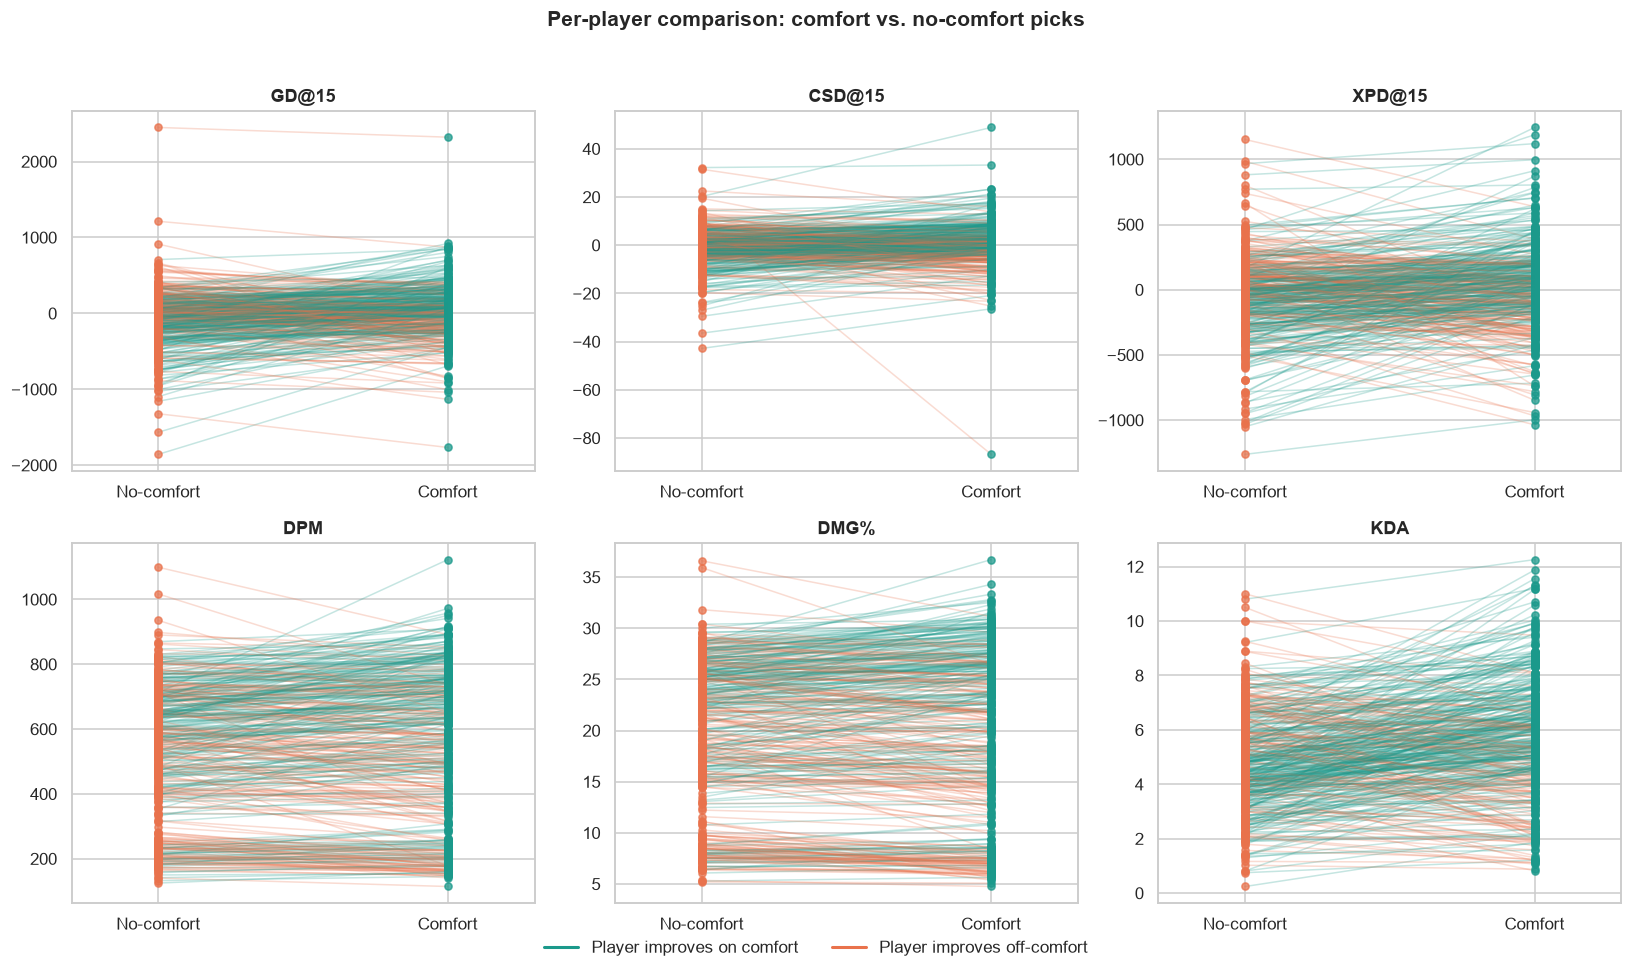

In [5]:
def plot_paired_small_multiples(wide_df: pd.DataFrame, metrics_dict: dict,
                                 save_name: str = "fig2_paired_comparison_by_metric"):
    n = len(metrics_dict)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for ax, (metric, label) in zip(axes, metrics_dict.items()):
        comfort_col, nocomfort_col = f"{metric}_comfort", f"{metric}_nocomfort"
        if comfort_col not in wide_df.columns or nocomfort_col not in wide_df.columns:
            ax.set_visible(False)
            continue
        for _, row in wide_df.iterrows():
            improves = row[comfort_col] > row[nocomfort_col]
            color = COLOR_COMFORT if improves else COLOR_NOCOMFORT
            ax.plot([0, 1], [row[nocomfort_col], row[comfort_col]], color=color, alpha=0.25, linewidth=1)
        ax.scatter([0] * len(wide_df), wide_df[nocomfort_col], color=COLOR_NOCOMFORT, s=22, alpha=0.75, zorder=3)
        ax.scatter([1] * len(wide_df), wide_df[comfort_col], color=COLOR_COMFORT, s=22, alpha=0.75, zorder=3)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["No-comfort", "Comfort"])
        ax.set_title(label, fontweight="bold")
        ax.set_xlim(-0.3, 1.3)

    for ax in axes[n:]:
        ax.set_visible(False)

    legend_elems = [
        Line2D([0], [0], color=COLOR_COMFORT, lw=2, label="Player improves on comfort"),
        Line2D([0], [0], color=COLOR_NOCOMFORT, lw=2, label="Player improves off-comfort"),
    ]
    fig.legend(handles=legend_elems, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Per-player comparison: comfort vs. no-comfort picks", fontsize=14, fontweight="bold", y=1.02)
    fig.tight_layout()
    save_fig(fig, save_name)
    plt.show()


plot_paired_small_multiples(wide, ALL_METRICS)

## Figure 3 — Comfort-effect heterogeneity by role

Boxplot of the per-player comfort effect (the BLUP-based estimate from the random-slope model in `03`, Part 2 extension) grouped by role. Each dot is one player; size and opacity scale with how many games they contributed — a small, faint dot is a less reliable individual estimate than a large, solid one.

Saved: assets/figures/fig3_comfort_effect_by_role.png
Saved: assets/figures/fig3_comfort_effect_by_role.svg


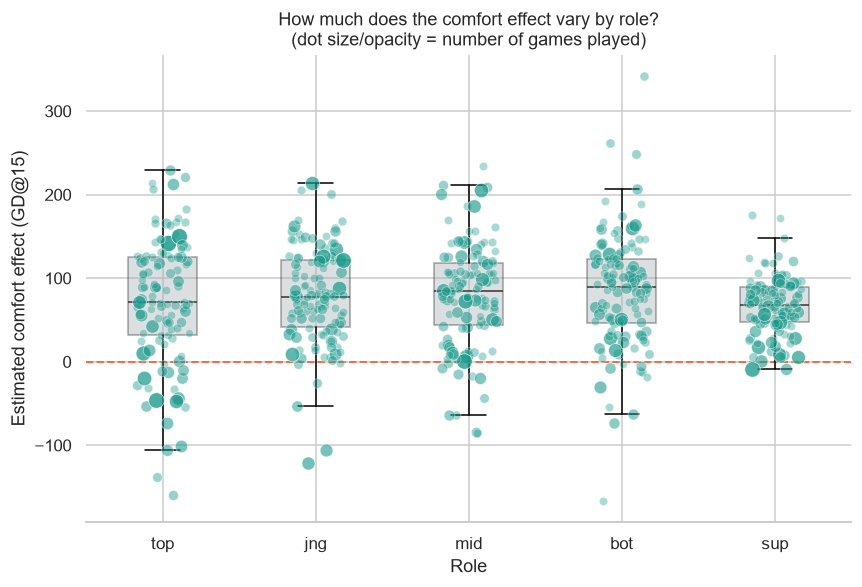

In [6]:
def plot_comfort_effect_by_role(comfort_effect_df: pd.DataFrame,
                                 save_name: str = "fig3_comfort_effect_by_role"):
    metric_label = comfort_effect_df["metric"].iloc[0] if "metric" in comfort_effect_df.columns else ""
    order = [p for p in ["top", "jng", "mid", "bot", "sup"] if p in comfort_effect_df["position"].unique()]
    if not order:
        order = sorted(comfort_effect_df["position"].dropna().unique())
    pos_to_x = {p: i for i, p in enumerate(order)}

    fig, ax = plt.subplots(figsize=(8, 5.5))

    box_data = [
        comfort_effect_df.loc[comfort_effect_df["position"] == p, "comfort_effect_player"].dropna()
        for p in order
    ]
    bp = ax.boxplot(box_data, positions=range(len(order)), widths=0.45, showfliers=False, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor(COLOR_NEUTRAL)
        patch.set_alpha(0.35)
    for median_line in bp["medians"]:
        median_line.set_color("#333333")

    rng = np.random.default_rng(42)
    max_games = comfort_effect_df["n_games_total"].max()
    for _, row in comfort_effect_df.iterrows():
        if row["position"] not in pos_to_x:
            continue
        x = pos_to_x[row["position"]] + rng.uniform(-0.18, 0.18)
        weight = row["n_games_total"] / max_games if max_games else 0.5
        size = 25 + 90 * weight
        alpha = 0.35 + 0.5 * weight
        ax.scatter(x, row["comfort_effect_player"], s=size, alpha=alpha, color=COLOR_COMFORT,
                   edgecolor="white", linewidth=0.5, zorder=3)

    ax.axhline(0, color=COLOR_NOCOMFORT, linestyle="--", linewidth=1.3, zorder=1)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order)
    ax.set_xlabel("Role")
    ax.set_ylabel(f"Estimated comfort effect ({metric_label})")
    ax.set_title("How much does the comfort effect vary by role?\n(dot size/opacity = number of games played)")
    sns.despine(left=True)
    fig.tight_layout()
    save_fig(fig, save_name)
    plt.show()


plot_comfort_effect_by_role(comfort_effect)

## Figure 4 — Top and bottom players by comfort effect

Ranking of players by their estimated comfort effect (BLUP), showing the top and bottom N. Bar opacity again scales with sample size (`n_games_total`), so a coach glancing at this figure can tell a well-supported estimate from a noisy one at a glance.

Saved: assets/figures/fig4_top_bottom_players.png
Saved: assets/figures/fig4_top_bottom_players.svg


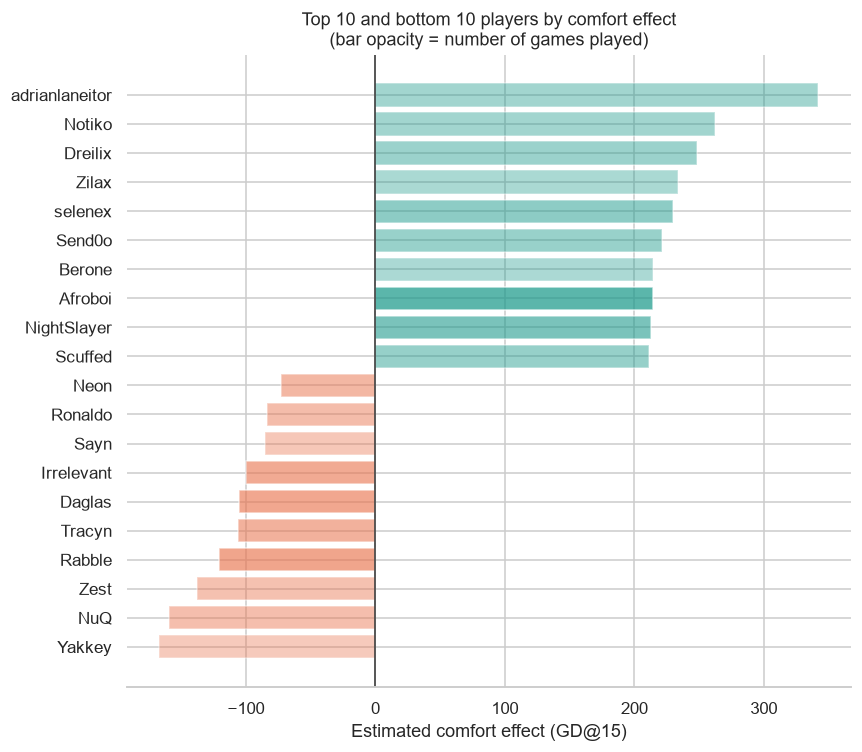

In [7]:
def plot_top_bottom_players(comfort_effect_df: pd.DataFrame, n: int = 10,
                             save_name: str = "fig4_top_bottom_players"):
    metric_label = comfort_effect_df["metric"].iloc[0] if "metric" in comfort_effect_df.columns else ""
    ranked = comfort_effect_df.sort_values("comfort_effect_player", ascending=False)
    top = ranked.head(n)
    bottom = ranked.tail(n).sort_values("comfort_effect_player", ascending=False)
    combined = pd.concat([top, bottom])

    max_games = comfort_effect_df["n_games_total"].max()
    colors = [COLOR_COMFORT if v >= 0 else COLOR_NOCOMFORT for v in combined["comfort_effect_player"]]
    alphas = 0.35 + 0.55 * (combined["n_games_total"] / max_games if max_games else 0.5)

    fig, ax = plt.subplots(figsize=(8, max(5, 0.35 * len(combined))))
    y = np.arange(len(combined))
    bars = ax.barh(y, combined["comfort_effect_player"], color=colors)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(float(a))

    ax.set_yticks(y)
    ax.set_yticklabels(combined["playername"])
    ax.invert_yaxis()
    ax.axvline(0, color="#333333", linewidth=1)
    ax.set_xlabel(f"Estimated comfort effect ({metric_label})")
    ax.set_title(f"Top {n} and bottom {n} players by comfort effect\n(bar opacity = number of games played)")
    sns.despine(left=True)
    fig.tight_layout()
    save_fig(fig, save_name)
    plt.show()


plot_top_bottom_players(comfort_effect)

## Figure 5 — Selection bias check: comfort share by relative opponent strength

If comfort-pick assignment were independent of relative team strength, the share of comfort games would look roughly flat across `elo_diff_z` quintiles. A visible slope here is direct, visual evidence of the endogeneity discussed in Part 3 of `03_stats_analysis.ipynb` — it complements (doesn't replace) the logistic-regression check run there.

Saved: assets/figures/fig5_selection_bias_by_elo_quintile.png
Saved: assets/figures/fig5_selection_bias_by_elo_quintile.svg


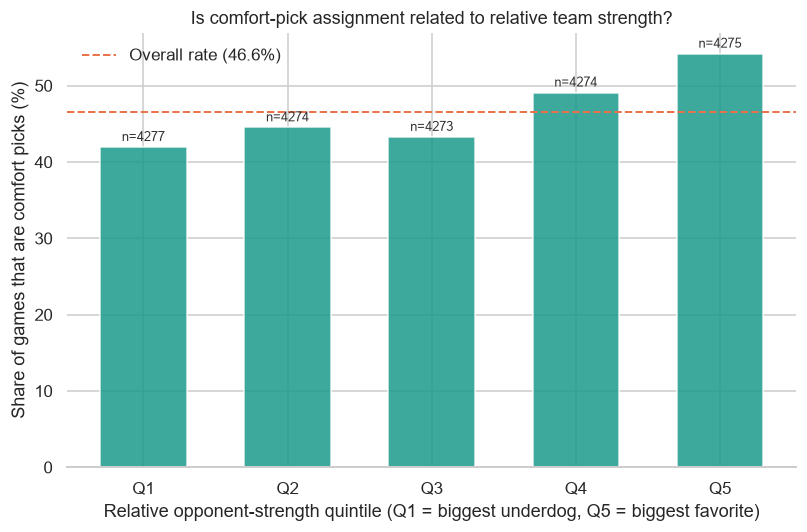

In [8]:
def plot_selection_bias(model_df: pd.DataFrame, save_name: str = "fig5_selection_bias_by_elo_quintile"):
    d = model_df.dropna(subset=["elo_diff_z", "is_comfort"]).copy()
    d["elo_quintile"] = pd.qcut(d["elo_diff_z"], 5, labels=[f"Q{i + 1}" for i in range(5)])
    summary = d.groupby("elo_quintile", observed=True)["is_comfort"].agg(["mean", "count"]).reset_index()
    summary["mean_pct"] = summary["mean"] * 100

    fig, ax = plt.subplots(figsize=(7.5, 5))
    bars = ax.bar(summary["elo_quintile"], summary["mean_pct"], color=COLOR_COMFORT, alpha=0.85, width=0.6)
    overall_rate = d["is_comfort"].mean() * 100
    ax.axhline(overall_rate, color=COLOR_NOCOMFORT, linestyle="--", linewidth=1.3,
               label=f"Overall rate ({overall_rate:.1f}%)")

    for bar, n_games in zip(bars, summary["count"]):
        ax.annotate(f"n={n_games}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=8.5, color="#333333")

    ax.set_xlabel("Relative opponent-strength quintile (Q1 = biggest underdog, Q5 = biggest favorite)")
    ax.set_ylabel("Share of games that are comfort picks (%)")
    ax.set_title("Is comfort-pick assignment related to relative team strength?")
    ax.legend(frameon=False)
    sns.despine(left=True)
    fig.tight_layout()
    save_fig(fig, save_name)
    plt.show()


plot_selection_bias(model_df)

## Summary

Five figures saved as PNG (300 dpi, for slides/README) and SVG (for further editing) to `assets/figures/`:

| File | What it shows |
|---|---|
| `fig1_forest_lmm_comfort_effect` | Standardized comfort effect per metric, with significance |
| `fig2_paired_comparison_by_metric` | Per-player comfort vs. no-comfort paired means |
| `fig3_comfort_effect_by_role` | Heterogeneity of the comfort effect across roles |
| `fig4_top_bottom_players` | Players who benefit most / least from comfort picks |
| `fig5_selection_bias_by_elo_quintile` | Evidence of (non-random) comfort-pick assignment |

Next step for the portfolio write-up: embed these in the README alongside a short interpretation of each, and be explicit that Figure 1 reports an **adjusted association**, not a causal effect — Part 3 of `03_stats_analysis.ipynb` explains why, and what it would take to get closer to a causal claim.